<a href="https://colab.research.google.com/github/soheilesteki333/Wine-Quality-Analytics/blob/main/Wine%20Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




#=============================
# Task
Perform an exploratory data analysis (EDA) on the `winequality-white.csv` dataset, including displaying basic statistics, visualizing data distributions, detecting outliers, and analyzing correlations between features. Summarize the key findings from the EDA.

*italicized text*## Load Dataset

### Subtask:
Load the `winequality-white.csv` dataset into a pandas DataFrame.


**Reasoning**:
To load the dataset, I need to first import the pandas library, then use `pd.read_csv` to load the `winequality-white.csv` file. After loading, I will display the first 5 rows using `df.head()` and show column information with `df.info()` to verify the data was loaded correctly and understand its structure.



In [ ]:
import pandas as pd

# Load the dataset into a pandas DataFrame
# Use ',' as a separator and skip the metadata rows at original file indices 1 and 2
df = pd.read_csv('winequality-white.csv', sep=',', skiprows=[1, 2])

# Display the first 5 rows of the DataFrame
print('First 5 rows of the DataFrame:')
print(df.head())

# Display the column names and their data types
print('\nColumn names and their data types:')
print(df.info())

First 5 rows of the DataFrame:
   quality  fixed acidity  volatile acidity  citric acid  residual sugar  \
0        6            7.0              0.27         0.36            20.7   
1        6            6.3              0.30         0.34             1.6   
2        6            8.1              0.28         0.40             6.9   
3        6            7.2              0.23         0.32             8.5   
4        6            7.2              0.23         0.32             8.5   

   chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  \
0      0.045                 45.0                 170.0   1.0010  3.00   
1      0.049                 14.0                 132.0   0.9940  3.30   
2      0.050                 30.0                  97.0   0.9951  3.26   
3      0.058                 47.0                 186.0   0.9956  3.19   
4      0.058                 47.0                 186.0   0.9956  3.19   

   sulphates  alcohol  
0       0.45      8.8  
1       0.49      9

## Display Basic Statistics

### Subtask:
Display basic descriptive statistics of the dataset, including mean, median, standard deviation, min, and max for all numerical columns. This will provide an initial understanding of the data distribution.


**Reasoning**:
To display basic descriptive statistics, I will use the `.describe()` method on the DataFrame `df` as instructed, which provides statistics like mean, standard deviation, min, max, and quartiles for all numerical columns. I will then print the result.



In [ ]:
print('Descriptive Statistics of the Dataset:')
print(df.describe())

Descriptive Statistics of the Dataset:
           quality  fixed acidity  volatile acidity  citric acid  \
count  4898.000000    4898.000000       4898.000000  4898.000000   
mean      5.877909       6.854788          0.278241     0.334192   
std       0.885639       0.843868          0.100795     0.121020   
min       3.000000       3.800000          0.080000     0.000000   
25%       5.000000       6.300000          0.210000     0.270000   
50%       6.000000       6.800000          0.260000     0.320000   
75%       6.000000       7.300000          0.320000     0.390000   
max       9.000000      14.200000          1.100000     1.660000   

       residual sugar    chlorides  free sulfur dioxide  total sulfur dioxide  \
count     4898.000000  4898.000000          4898.000000           4898.000000   
mean         6.391415     0.045772            35.308085            138.360657   
std          5.072058     0.021848            17.007137             42.498065   
min          0.600000   

## Visualize Data Distribution

### Subtask:
Generate histograms for all numerical features to visualize their distributions and identify potential skewness or anomalies.


**Reasoning**:
To visualize the distribution of all numerical features, I will generate histograms for each column. This involves importing `matplotlib.pyplot` and `seaborn`, creating a subplot grid, iterating through the DataFrame columns to plot histograms using `sns.histplot`, setting titles, adjusting the layout, and finally displaying the plots.



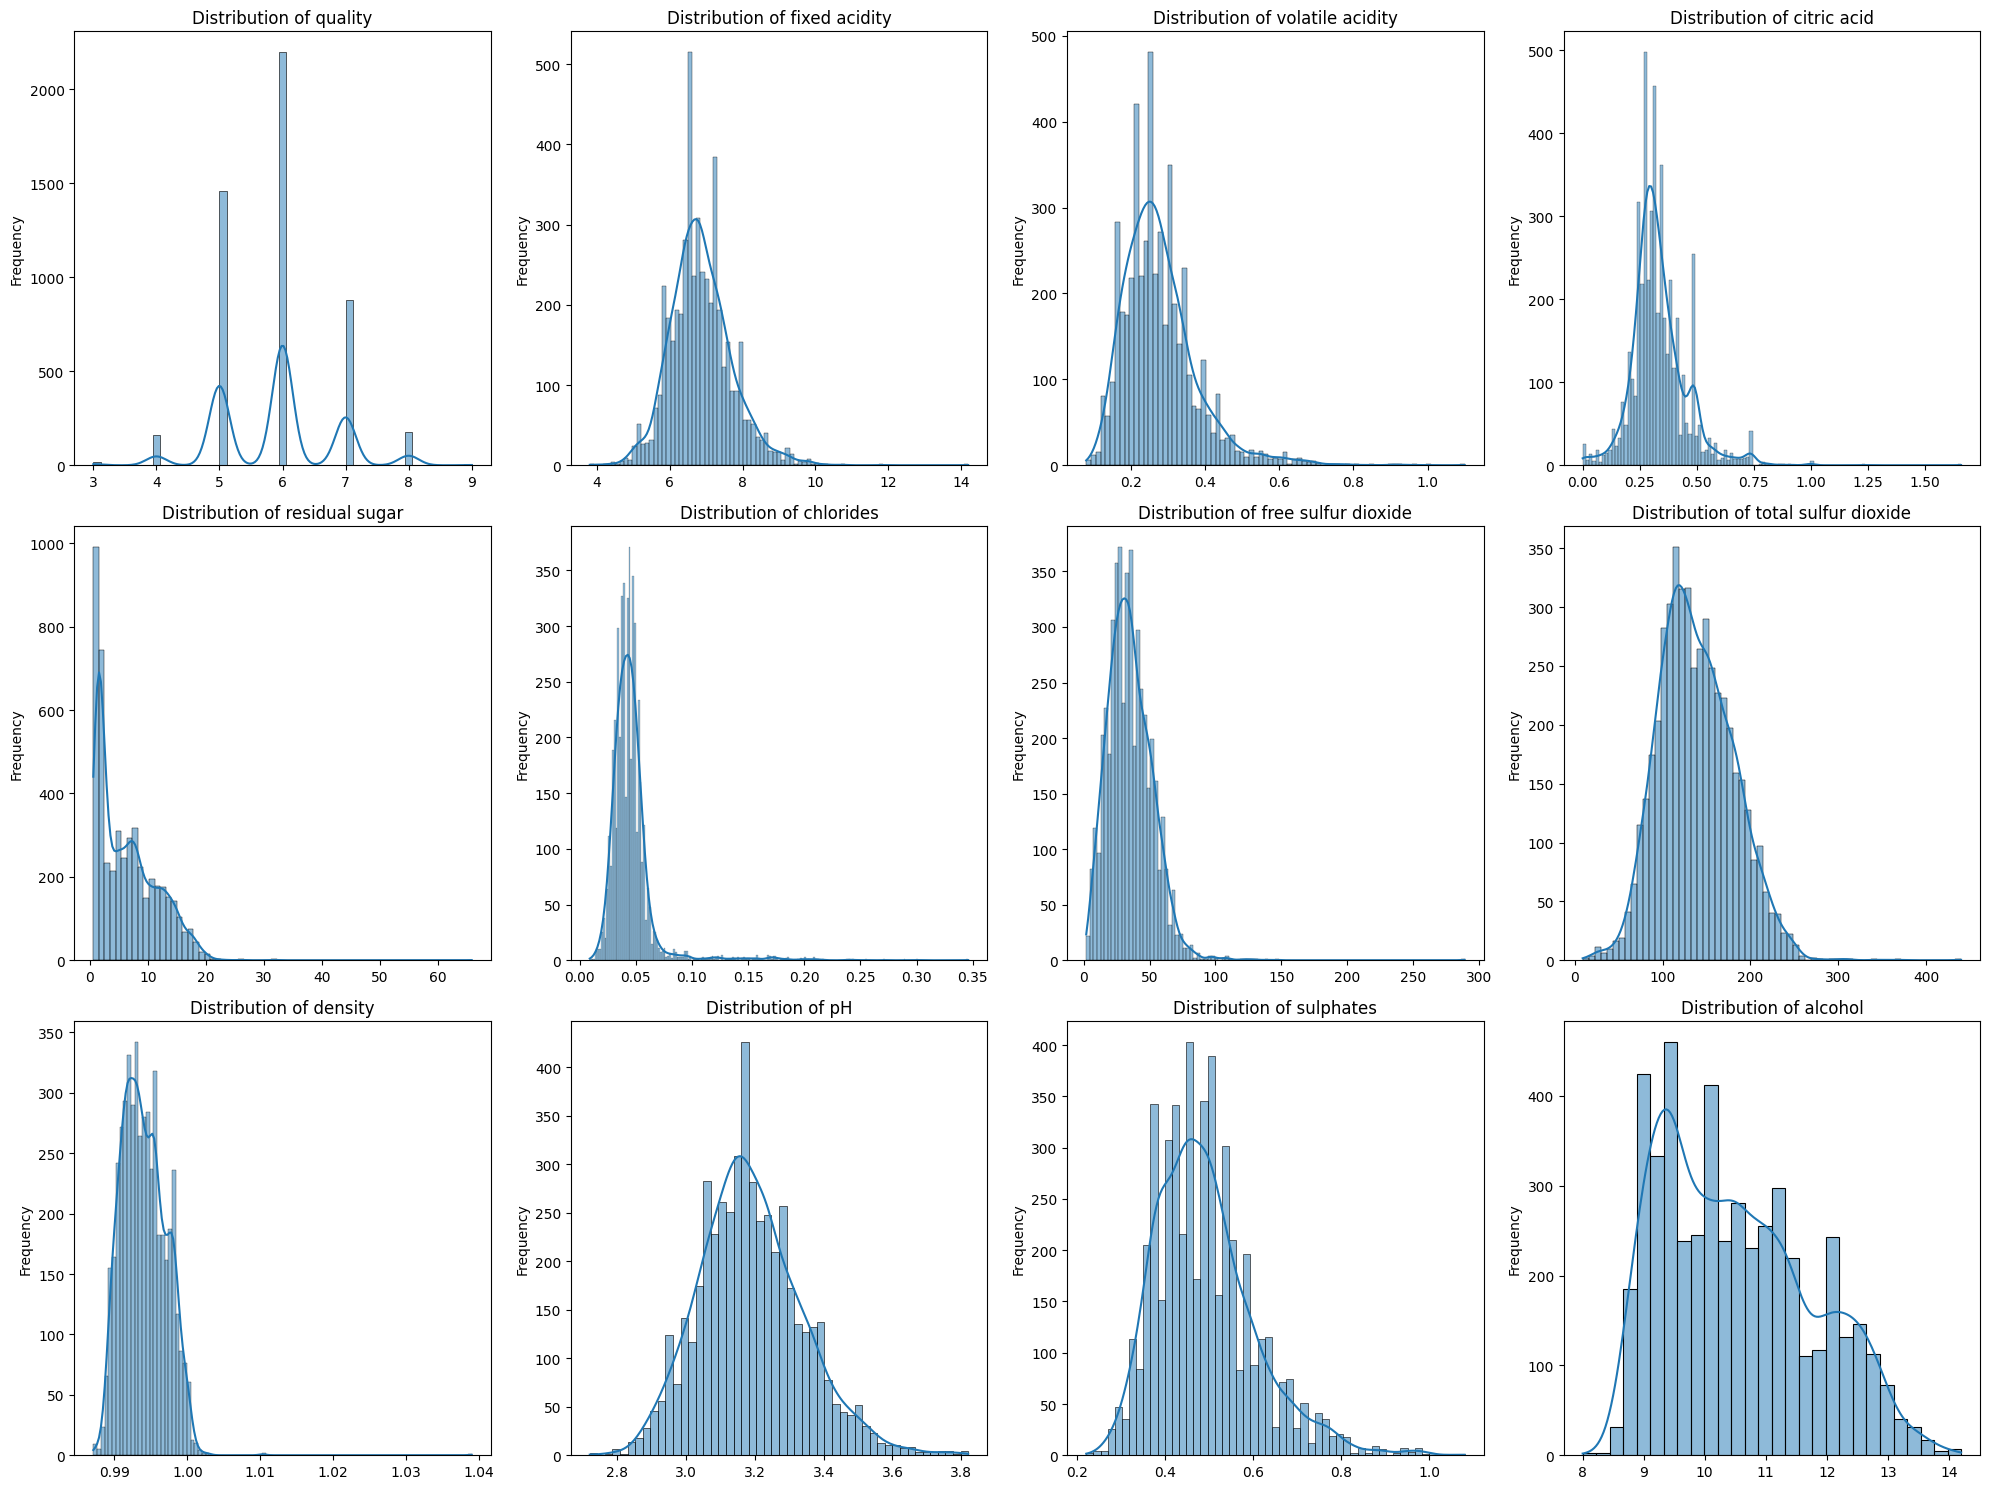

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and a set of subplots for histograms
# Assuming df has 12 columns, a 3x4 grid is suitable
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten() # Flatten the 3x4 array of axes to easily iterate

# Iterate through each column and plot a histogram
for i, column in enumerate(df.columns):
    sns.histplot(df[column], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel('') # Clear x-axis label to avoid clutter, title is sufficient
    axes[i].set_ylabel('Frequency')

# Adjust the layout to prevent titles and labels from overlapping
plt.tight_layout()

# Display the plots
plt.show()

## Outlier Detection

### Subtask:
Perform outlier detection using methods like IQR (Interquartile Range) or Z-score for relevant numerical columns and visualize them using box plots.


**Reasoning**:
To perform outlier detection visually, I will generate box plots for each numerical column. This involves creating a grid of subplots, iterating through the DataFrame's columns, plotting a box plot for each using `seaborn.boxplot`, and then displaying them with appropriate titles and layout adjustments.



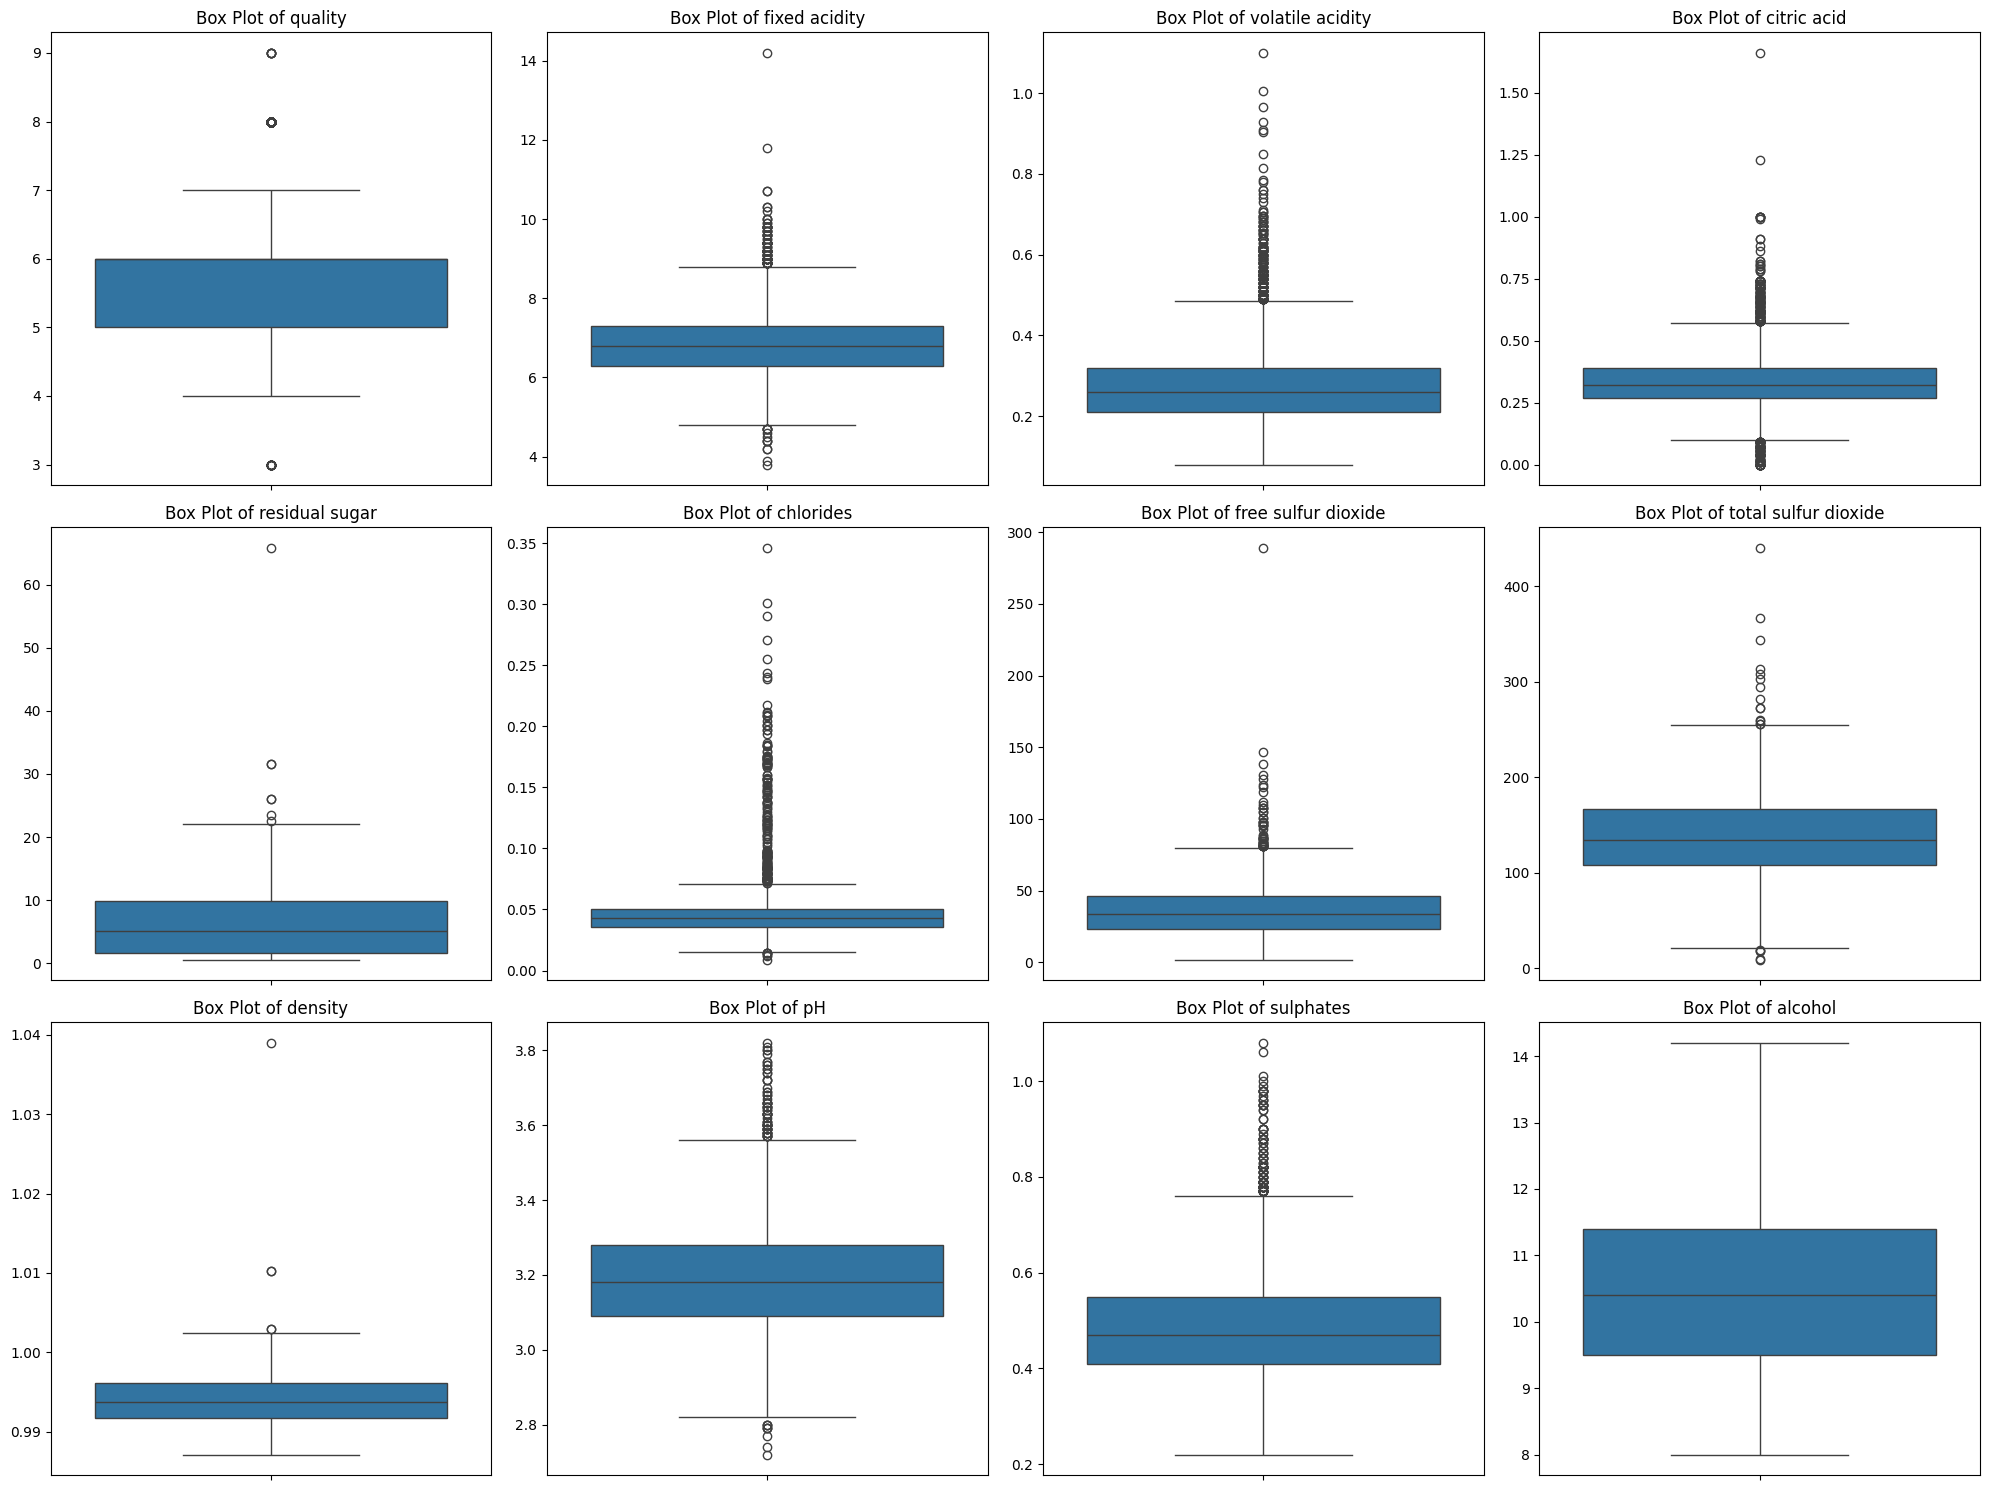

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and a set of subplots for box plots
# Assuming df has 12 columns, a 3x4 grid is suitable
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten() # Flatten the 3x4 array of axes to easily iterate

# Iterate through each column and plot a box plot
for i, column in enumerate(df.columns):
    sns.boxplot(y=df[column], ax=axes[i])
    axes[i].set_title(f'Box Plot of {column}')
    axes[i].set_ylabel('') # Clear y-axis label to avoid clutter, title is sufficient

# Adjust the layout to prevent titles and labels from overlapping
plt.tight_layout()

# Display the plots
plt.show()

## Correlation Analysis

### Subtask:
Calculate and visualize the correlation matrix of the features to understand relationships between different variables using a heatmap. Provide appropriate legends.


**Reasoning**:
To visualize the correlation matrix as requested, I will calculate the correlation matrix using `df.corr()` and then use `seaborn.heatmap()` with specified parameters for annotations, colormap, and title. Finally, I will display the plot.



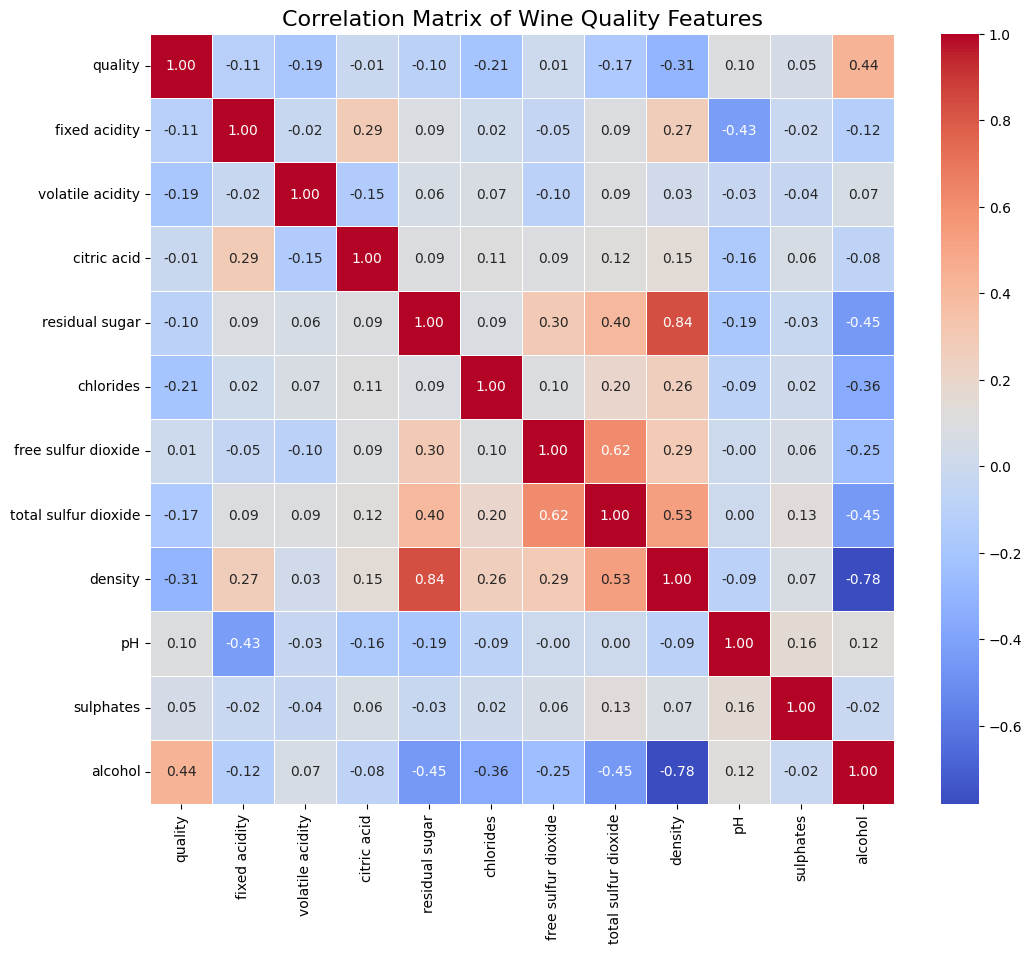

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

# Add a title to the heatmap
plt.title('Correlation Matrix of Wine Quality Features', fontsize=16)

# Display the plot
plt.show()

## Final Task

### Subtask:
Summarize the key findings from the EDA, including insights from basic statistics, data distributions, identified outliers, and correlations between features.


## Summary:

### Data Analysis Key Findings

*   **Dataset Overview**: The dataset contains 4898 non-null entries across 12 numerical features, indicating no missing values.
*   **Wine Quality Distribution**: Wine quality scores range from 3 to 9, with a mean of approximately 5.88 and a standard deviation of 0.89, suggesting that most wines fall within a relatively narrow quality spectrum.
*   **Feature Variability and Potential Skewness/Outliers**:
    *   `residual sugar` exhibits a very wide range (0.6 to 65.8) and a high standard deviation (5.07), suggesting a highly skewed distribution with significant outliers.
    *   `free sulfur dioxide` (maximum of 289) and `total sulfur dioxide` (maximum of 440) also show considerably large maximum values compared to their means and 75th percentiles, indicating the presence of potential outliers.
    *   In contrast, `density` values are very tightly clustered around a mean of 0.994, with a very small standard deviation.
*   **Visual Confirmation of Distributions and Outliers**: Histograms and box plots successfully visualized the distributions and confirmed the presence of outliers in several features, particularly those noted in the descriptive statistics (e.g., `residual sugar`, `free sulfur dioxide`, `total sulfur dioxide`).
*   **Inter-Feature Relationships**: A correlation matrix heatmap was successfully generated, providing a clear visualization of the linear relationships between all features, which included precise correlation values.

### Insights or Next Steps

*   Address the significant skewness and outliers observed in features like `residual sugar`, `free sulfur dioxide`, and `total sulfur dioxide` through appropriate data transformation or outlier handling techniques (e.g.,Winsorization, log transformation) before building predictive models.
*   Further investigate the features with strong correlations to `quality` (e.g., alcohol) and other features to understand their impact and potentially simplify the model by reducing dimensionality or creating new features.


# Task
Create a scatter plot using the `df` DataFrame to visualize the relationship between 'quality' and 'alcohol' percentage, labeling the x-axis as 'Alcohol Percentage', the y-axis as 'Quality', and giving the plot the title 'Quality vs. Alcohol Percentage'.

## Generate Scatter Plot

### Subtask:
Create a scatter plot using seaborn to visualize the relationship between 'quality' and 'alcohol' percentage. The plot will include appropriate axis labels and a title.


**Reasoning**:
To visualize the relationship between 'quality' and 'alcohol' percentage, I will create a scatter plot using `seaborn.scatterplot` and add appropriate labels and a title.



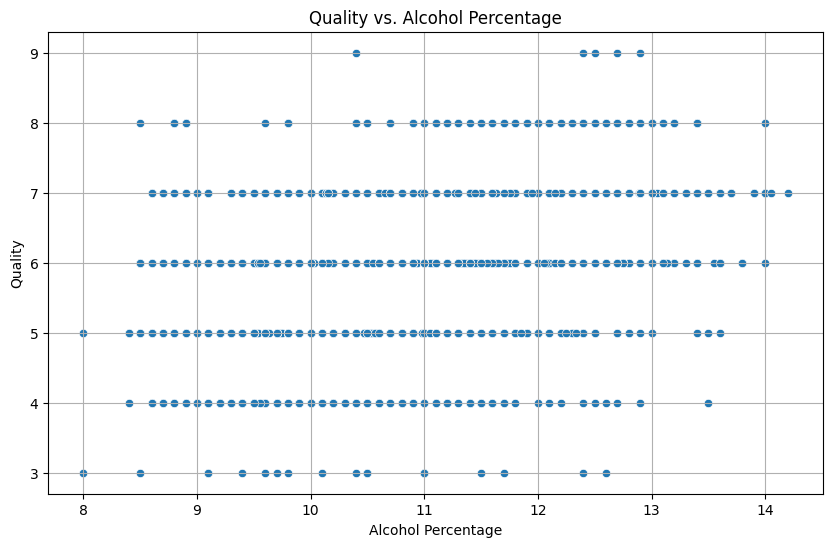

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='alcohol', y='quality')

# Set labels and title
plt.xlabel('Alcohol Percentage')
plt.ylabel('Quality')
plt.title('Quality vs. Alcohol Percentage')

# Display the plot
plt.grid(True)
plt.show()

## Final Task

### Subtask:
Provide a summary of the insights observed from the scatter plot, including any apparent trends or correlations between quality and alcohol percentage.


## Summary:

### Q&A
The current solving process focused on generating the scatter plot; therefore, no direct insights or observed trends regarding the correlation between quality and alcohol percentage from the plot are available within the provided steps.

### Data Analysis Key Findings
*   The `matplotlib.pyplot` and `seaborn` libraries were successfully imported and utilized for data visualization.
*   A scatter plot was effectively generated to visualize the relationship between 'quality' and 'alcohol' percentage from the DataFrame.
*   The plot was appropriately configured with 'Alcohol Percentage' as the x-axis label, 'Quality' as the y-axis label, and 'Quality vs. Alcohol Percentage' as its title.
*   The successful execution resulted in the display of the scatter plot, fulfilling the visualization requirements.

### Insights or Next Steps
*   The scatter plot is now available for visual inspection to identify any apparent trends, patterns, or correlations between wine quality and alcohol percentage.
*   Further analysis would involve interpreting the generated plot to quantify or describe the observed relationships, addressing the initial task of summarizing insights and correlations.


# Task
Generate a histogram or count plot to visualize the distribution of the 'quality' variable, including appropriate labels and a title.

## Visualize Target Distribution

### Subtask:
Generate a histogram or count plot to visualize the distribution of the 'quality' variable, providing insights into its frequency and spread. Ensure appropriate labels and a title are included.


**Reasoning**:
To visualize the distribution of the 'quality' variable as instructed, I will use `seaborn.countplot` to create a count plot and ensure it has appropriate labels and a title.



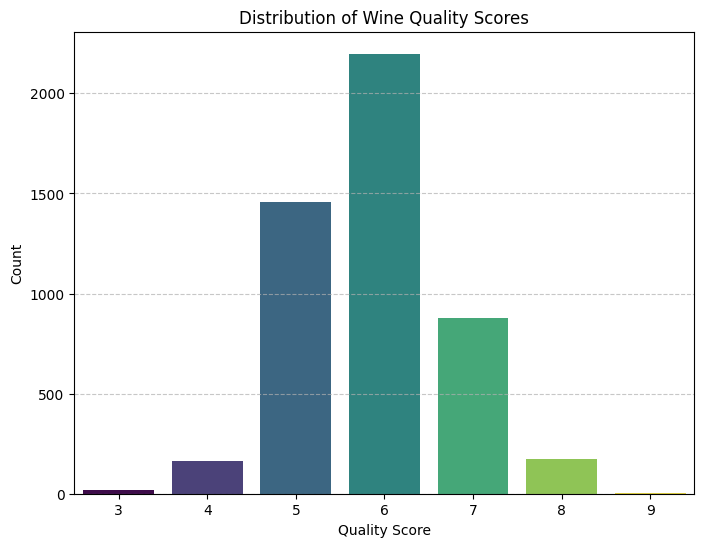

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for better readability
plt.figure(figsize=(8, 6))

# Create a count plot for the 'quality' column
sns.countplot(x='quality', data=df, palette='viridis', hue='quality', legend=False)

# Set the x-axis label
plt.xlabel('Quality Score')

# Set the y-axis label
plt.ylabel('Count')

# Set the title of the plot
plt.title('Distribution of Wine Quality Scores')

# Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **Attention: This is the end of this part, for continuing please open the next link.**
==================================================











## The Link of Part 2: https://colab.research.google.com/drive/1WdEsZBsbgXEyw6NoQPzex6iRejd-VQc5?usp=sharing
